In [ ]:
import pandas as pd
import numpy as np
import os

data = pd.read_csv(os.path.join("..", "wide_sta_observations.csv"), parse_dates=["period_date"])
data.rename(columns={"period_date": "date"}, inplace=True)
metadata = pd.read_csv(os.path.join("..", "all_metadata.csv"))

target_variable = "66" 
lags = list(range(-2, 3)) 

train_start_date = "2000-01-01"
test_start_date = "2018-03-01" 
test_end_date = "2023-12-01"

test = data.loc[
    (data.date >= train_start_date) & 
    (data.date <= test_end_date)
].reset_index(drop=True)

print(f"Duomenų rėžių patikra: Nuo {test.date.min()} iki {test.date.max()}")

Duomenų rėžių patikra: Nuo 2000-01-01 00:00:00 iki 2023-12-01 00:00:00


In [ ]:
# kodas iš: https://github.com/dhopp1/nowcasting_benchmark/tree/main/methodologies

# Generuojami suvėlinti duomenų rinkiniai testavimui pagal informacijos prieinamumo laikotarpius (vintages)
def gen_lagged_data(metadata, data, last_date, lag):
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    metadata['series_id'] = metadata['series_id'].astype(str)
    for col in lagged_data.columns[1:]:
        pub_lag = metadata.loc[metadata.series_id == col, "months_lag"].values[0] # Konkretaus kintamojo paskelbimo vėlavimas
        # Reikšmės paslepiamos (NaN) atsižvelgiant į paskelbimo vėlavimą ir pasirinktą modeliavimo momentą (lag)
        lagged_data.loc[(len(lagged_data) - pub_lag + lag) :, col] = np.nan

    return lagged_data

# Ankstenių mėnesių reikšmių įtraukimas (kaip atskiri kintamieji)
def flatten_data(data, target_variable, n_lags):
    flattened_data = data.loc[~pd.isna(data[target_variable]), :]
    orig_index = flattened_data.index
    for i in range(1, n_lags + 1):
        lagged_indices = orig_index - i
        lagged_indices = lagged_indices[lagged_indices >= 0]
        tmp = data.loc[lagged_indices, :]
        tmp.date = tmp.date + pd.DateOffset(months=i)
        tmp = tmp.drop([target_variable], axis=1)
        tmp.columns = [j + "_" + str(i) if j != "date" else j for j in tmp.columns]
        flattened_data = flattened_data.merge(tmp, how="left", on="date")

    return flattened_data

# Praleistų reikšmių užpildymas naudojant mokymo rinkinio vidurkį
def mean_fill_dataset(training, test):
    mean_dict = {}
    for col in training.columns[1:]:
        mean_dict[col] = np.nanmean(training[col])
    filled = test.copy()
    for col in training.columns[1:]:
        filled.loc[pd.isna(filled[col]), col] = mean_dict[col]
    return filled

In [3]:
dates = (
        pd.date_range(test_start_date, test_end_date, freq="3MS")
        .strftime("%Y-%m-%d")
        .tolist()
    )

actuals = list(test.loc[test.date.isin(dates), target_variable].values)

/tmp/ipykernel_1467925/32520634.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  actuals = list(test.loc[test.date.isin(dates), target_variable].values)


# Paieškos gardelė

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

train_data = test.loc[test.date < test_start_date].copy()

lags_to_test = [6, 7, 8, 9, 10] 
best_overall_rmse = float('inf')
best_overall_params = None
best_overall_lags = None

# Kryžminė patikra
tscv = TimeSeriesSplit(n_splits=5)

for nl in lags_to_test:
    print(f"--- Testuojamas n_lags: {nl} ---")
    
    # Duomenų paruošimas konkrečiam istorijos gyliui
    df_flat = flatten_data(train_data, target_variable, n_lags=nl)
    df_model = df_flat.loc[df_flat.date.dt.month.isin([3, 6, 9, 12]), :].dropna(subset=[target_variable])

    X_gs = df_model.drop(["date", target_variable], axis=1)
    y_gs = df_model[target_variable]

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()), 
        ('xgb', XGBRegressor(random_state=42, n_jobs=-1))
    ])

    param_grid = {
        'xgb__max_depth': [1, 2, 3],           
        'xgb__n_estimators': [1250, 1500, 2000],     
        'xgb__learning_rate': [0.05, 0.07, 0.1],    
        'xgb__reg_lambda': [5, 10, 20],            
        'xgb__reg_alpha': [0, 0.01, 1]               
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )
    
    grid_search.fit(X_gs, y_gs)
    
    current_rmse = abs(grid_search.best_score_)
    print(f"Geriausias RMSE su {nl} lagais: {current_rmse:.4f}")

    # Išsaugome geriausią rezultatą per visus n_lags
    if current_rmse < best_overall_rmse:
        best_overall_rmse = current_rmse
        best_overall_params = grid_search.best_params_
        best_overall_lags = nl

print("\n" + "="*30)
print(f"REZULTATAI:")
print(f"Geriausias n_lags: {best_overall_lags}")
print(f"Geriausi modelio parametrai: {best_overall_params}")
print(f"Minimalus validavimo RMSE: {best_overall_rmse:.4f}")

--- Testuojamas n_lags: 6 ---
Geriausias RMSE su 6 lagais: 1.6353
--- Testuojamas n_lags: 7 ---
Geriausias RMSE su 7 lagais: 1.6319
--- Testuojamas n_lags: 8 ---
Geriausias RMSE su 8 lagais: 1.5889
--- Testuojamas n_lags: 9 ---
Geriausias RMSE su 9 lagais: 1.5831
--- Testuojamas n_lags: 10 ---
Geriausias RMSE su 10 lagais: 1.6343

REZULTATAI:
Geriausias n_lags: 9
Geriausi modelio parametrai: {'xgb__learning_rate': 0.07, 'xgb__max_depth': 2, 'xgb__n_estimators': 1500, 'xgb__reg_alpha': 0, 'xgb__reg_lambda': 10}
Minimalus validavimo RMSE: 1.5831


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

xgb_clean_params = {k.replace('xgb__', ''): v for k, v in best_overall_params.items()}

pred_dict_xgb = {k: [] for k in lags}

# Užsitikriname tikrąsias reikšmes (actuals) pagal testavimo datas
actuals = [test.loc[test.date == pd.to_datetime(d), target_variable].values[0] for d in dates]

for date in dates:
    target_date_ts = pd.to_datetime(date)
    
    train_base = test.loc[test.date <= str(target_date_ts - pd.tseries.offsets.DateOffset(months=3))[:10], :].copy()
    
    train_filled_base = mean_fill_dataset(train_base, train_base)
    
    transformed_train = flatten_data(train_filled_base, target_variable, best_overall_lags)
    transformed_train = transformed_train.loc[transformed_train.date.dt.month.isin([3, 6, 9, 12])].copy()
    
    transformed_train = transformed_train.dropna(subset=[target_variable]).reset_index(drop=True)
    
    X_train = transformed_train.drop(["date", target_variable], axis=1)
    y_train = transformed_train[target_variable]
    
    model = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()), 
        ('xgb', XGBRegressor(
            **xgb_clean_params,       
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    model.fit(X_train, y_train)
    
    # Ciklas per informacijos prieinamumo laikotarpius (-2, -1, 0, 1, 2)
    for lag in lags:
        tmp_data = gen_lagged_data(metadata, test, date, lag)
        
        tmp_data = mean_fill_dataset(train_base, tmp_data) 
        tmp_data = flatten_data(tmp_data, target_variable, best_overall_lags)
        
        X_test = tmp_data.loc[tmp_data.date == target_date_ts, X_train.columns]
        
        if not X_test.empty:
            pred = model.predict(X_test)[0]
            pred_dict_xgb[lag].append(pred)
        else:
            pred_dict_xgb[lag].append(np.nan)

# ==============================================================================
# REZULTATŲ IR METRIKŲ SKAIČIAVIMAS
# ==============================================================================
results_xgb = []

for lag in lags:
    valid_indices = ~np.isnan(pred_dict_xgb[lag])
    y_true = np.array(actuals)[valid_indices]
    y_pred = np.array(pred_dict_xgb[lag])[valid_indices]
    
    if len(y_true) > 0:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        
        results_xgb.append({
            "Vintage (Lag)": lag,
            "RMSE": rmse,
            "MAE": mae,
            "N_Predictions": len(y_true)
        })
    else:
        results_xgb.append({"Vintage (Lag)": lag, "RMSE": np.nan, "MAE": np.nan, "N_Predictions": 0})

performance_df_xgb = pd.DataFrame(results_xgb)
print("\n" + "="*50)
print("GALUTINIAI XGBOOST REZULTATAI TESTAVIMO AIBĖJE:")
print("="*50)
print(performance_df_xgb.round(5).to_string(index=False))


GALUTINIAI XGBOOST REZULTATAI TESTAVIMO AIBĖJE:
 Vintage (Lag)    RMSE     MAE  N_Predictions
            -2 2.75735 1.73990             24
            -1 2.61810 1.71101             24
             0 2.57453 1.65042             24
             1 2.61150 1.66154             24
             2 2.61129 1.66129             24


In [ ]:
import json

# Išsaugome prognozes į CSV
df_preds_xgb = pd.DataFrame(pred_dict_xgb)
df_preds_xgb.columns = [f"lag_{c}" for c in df_preds_xgb.columns]
df_preds_xgb['date'] = dates
df_preds_xgb['actual'] = actuals

df_preds_xgb.to_csv('predictions_xgboost.csv', index=False)
print("XGBoost prognozės sėkmingai išsaugotos į 'predictions_xgboost.csv'")

final_params_to_save = {
    "optimal_n_lags": best_overall_lags,
    "best_xgb_parameters": best_overall_params
}

# Išsaugome į JSON
with open('best_params_xgboost.json', 'w') as f:
    json.dump(final_params_to_save, f, indent=4)
print("Geriausi XGBoost parametrai išsaugoti į 'best_params_xgboost.json'")

XGBoost prognozės sėkmingai išsaugotos į 'predictions_xgboost.csv'
Geriausi XGBoost parametrai išsaugoti į 'best_params_xgboost.json'


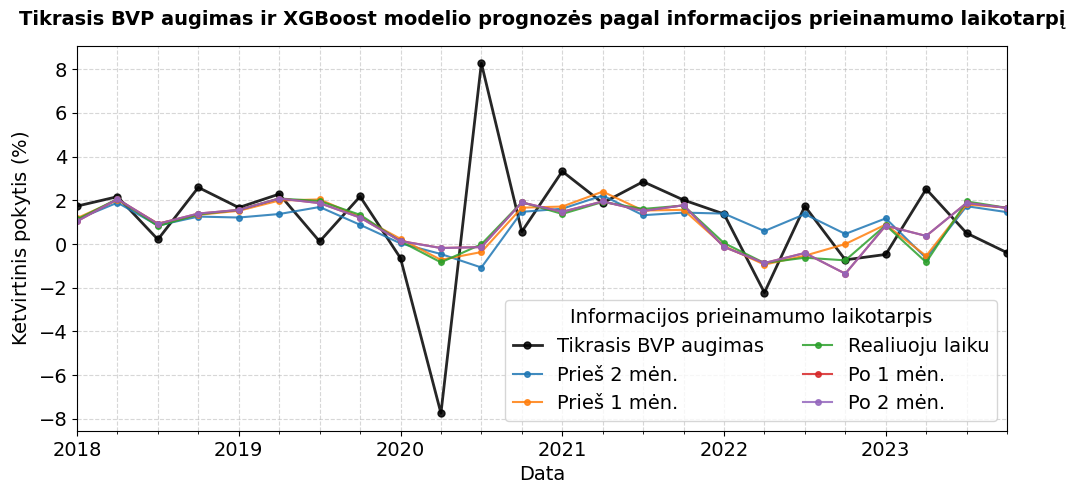

In [ ]:
import matplotlib.pyplot as plt

pred_dict_enet = pd.read_csv('predictions_xgboost.csv')
actuals = pred_dict_enet['actual']
dates = pred_dict_enet['date']

df_plot_enet = pd.DataFrame({
    "Tikrasis BVP augimas": actuals.values, 
    "Prieš 2 mėn.": pred_dict_enet['lag_-2'].values, 
    "Prieš 1 mėn.": pred_dict_enet['lag_-1'].values, 
    "Realiuoju laiku": pred_dict_enet['lag_0'].values,
    "Po 1 mėn.": pred_dict_enet['lag_1'].values,
    "Po 2 mėn.": pred_dict_enet['lag_2'].values
}, index=pd.to_datetime(dates))

# Grafikas
colors = ['black', 'C0', 'C1', 'C2', 'C3', 'C4']

ax = df_plot_enet.plot(
    figsize=(12, 5), 
    color=colors, 
    marker='o', 
    markersize=4, 
    linewidth=1.5, 
    alpha=0.85
)

ax.lines[0].set_linewidth(2)       
ax.lines[0].set_markersize(5)        

ax.lines[1].set_linestyle('-')       
ax.lines[2].set_linestyle('-')       
ax.lines[3].set_linestyle('-')       
ax.lines[4].set_linestyle('-')     
ax.lines[5].set_linestyle('-')      

plt.title("Tikrasis BVP augimas ir XGBoost modelio prognozės pagal informacijos prieinamumo laikotarpį", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Ketvirtinis pokytis ($\\%$)", fontsize=14)
plt.xlabel("Data", fontsize=14)

# Legenda
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title="Informacijos prieinamumo laikotarpis", loc='lower right', fontsize=14, title_fontsize=14, ncol=2, labelspacing=0.5, handlelength=1.5)

ax.tick_params(axis='both', which='major', labelsize=14)

plt.savefig('xgboost_nowcast_comparison.png', dpi=300, bbox_inches='tight')
plt.show()